In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [5]:
df=pd.read_csv('titanic_toy.csv')

In [6]:
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [7]:
df.isnull().sum()

Age         177
Fare         45
Family        0
Survived      0
dtype: int64

In [8]:
x=df.drop(['Survived'],axis=1)
y=df['Survived']
x_train,x_test,y_train,y_test=train_test_split(x,y,
                                               test_size=0.2,
                                               random_state=2)

In [9]:
x_train.shape

(712, 3)

In [10]:
y_train.shape

(712,)

<h1>Using Pandas</h1>

In [11]:
mean_age=x_train['Age'].mean()
median_age=x_train['Age'].median()

mean_fare=x_train['Fare'].mean()
median_fare=x_train['Fare'].median()

In [12]:
x_train['Age_median']=x_train['Age'].fillna(median_age)
x_train['Age_mean']=x_train['Age'].fillna(mean_age)

x_train['Fare_median']=x_train['Fare'].fillna(median_fare)
x_train['Fare_mean']=x_train['Fare'].fillna(mean_fare)

In [13]:
x_train.sample(5)

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
24,8.0,21.075,4,8.00,8.000000,21.075,21.075
806,39.0,0.000,0,39.00,39.000000,0.000,0.000
872,33.0,5.000,0,33.00,33.000000,5.000,5.000
16,2.0,29.125,5,2.00,2.000000,29.125,29.125
324,NaN,69.550,10,28.75,29.785904,69.550,69.550


In [14]:
#comparing variance before/after mean median imputation
print('Original Age variable variance: ', x_train['Age'].var())
print('Age Variance after median imputation: ', x_train['Age_median'].var())
print('Age Variance after mean imputation: ', x_train['Age_mean'].var())

print('Original Fare variable variance: ', x_train['Fare'].var())
print('Fare Variance after median imputation: ', x_train['Fare_median'].var())
print('Fare Variance after mean imputation: ', x_train['Fare_mean'].var())

Original Age variable variance:  204.3495133904614
Age Variance after median imputation:  161.9895663346054
Age Variance after mean imputation:  161.81262452718673
Original Fare variable variance:  2448.197913706318
Fare Variance after median imputation:  2340.0910219753637
Fare Variance after mean imputation:  2324.2385256705547


<p>Avoid high changes in variance</p>

Text(0, 0.5, 'Density')

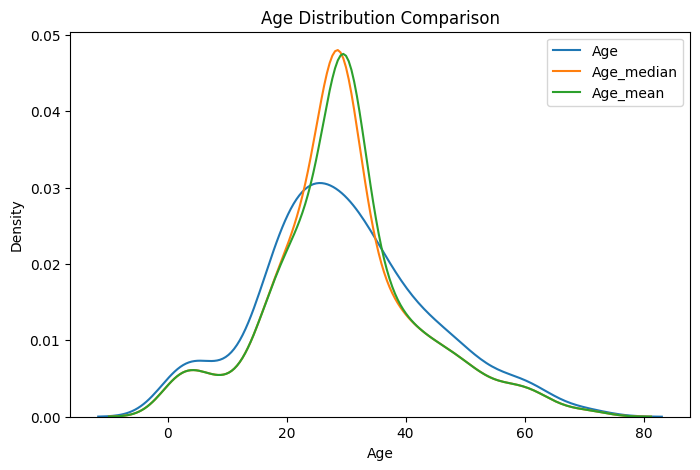

In [15]:
plt.figure(figsize=(8,5))

sns.kdeplot(x_train['Age'], label='Age')
sns.kdeplot(x_train['Age_median'], label='Age_median')
sns.kdeplot(x_train['Age_mean'], label='Age_mean')

plt.legend()
plt.title('Age Distribution Comparison')
plt.xlabel('Age')
plt.ylabel('Density')


<p>RED FLAG: TOO MUCH CHANGE IN DISTRUBUTION</p>

Text(0, 0.5, 'Density')

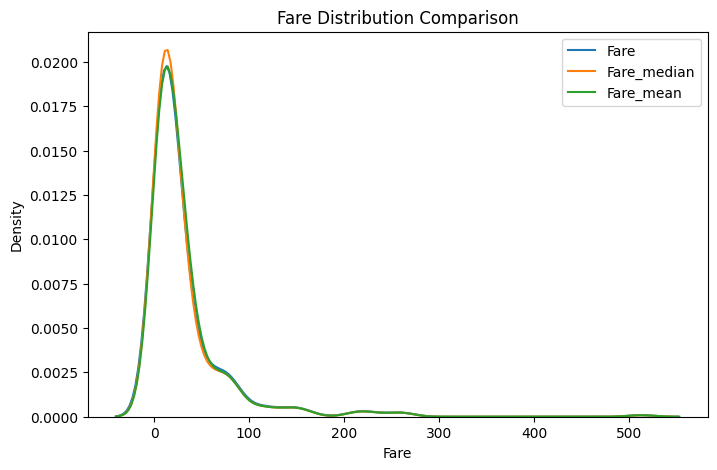

In [16]:
plt.figure(figsize=(8,5))

sns.kdeplot(x_train['Fare'], label='Fare')
sns.kdeplot(x_train['Fare_median'], label='Fare_median')
sns.kdeplot(x_train['Fare_mean'], label='Fare_mean')

plt.legend()
plt.title('Fare Distribution Comparison')
plt.xlabel('Fare')
plt.ylabel('Density')

<p>No significant change in distribution</p>

In [17]:
x_train.cov()

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
Age,204.349513,70.719262,-6.498901,204.349513,204.349513,64.858859,66.665205
Fare,70.719262,2448.197914,17.258917,57.957599,55.603719,2448.197914,2448.197914
Family,-6.498901,17.258917,2.735252,-5.112563,-5.146106,16.476305,16.385048
Age_median,204.349513,57.957599,-5.112563,161.989566,161.812625,53.553455,55.023037
Age_mean,204.349513,55.603719,-5.146106,161.812625,161.812625,51.358000,52.788341
Fare_median,64.858859,2448.197914,16.476305,53.553455,51.358000,2340.091022,2324.238526
Fare_mean,66.665205,2448.197914,16.385048,55.023037,52.788341,2324.238526,2324.238526


<h3>The effect is smaller for Fare because its original variance is already extremely large, while the effect is more noticeable for Age since replacing missing values changes its distribution more significantly. So, we can say that applying mean-median imputation on Age isnt a good decision.</h3>

<Axes: >

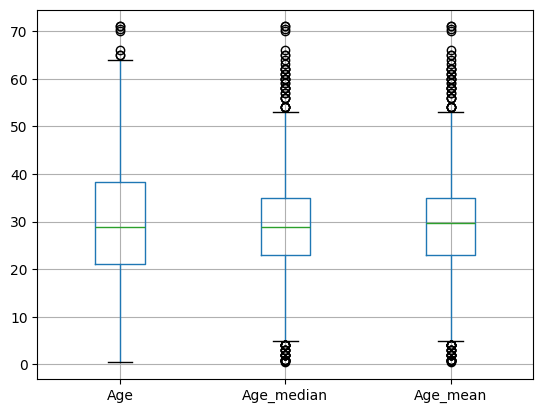

In [18]:
x_train[['Age','Age_median','Age_mean']].boxplot()

<p>RED FLAG: OUTLIERS ARE CREATED</p>

<Axes: >

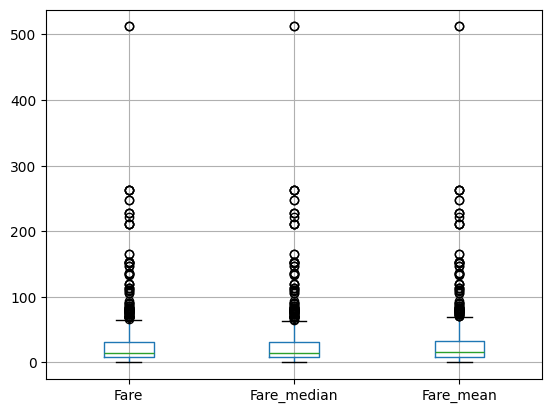

In [19]:
x_train[['Fare','Fare_median','Fare_mean']].boxplot()

<p>No Extra outliers created.</p>

<h1>Using Sklearn</h1>

In [20]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=2)

In [21]:
imputer1 = SimpleImputer(strategy='median')
imputer2 = SimpleImputer(strategy='mean')

trf = ColumnTransformer([
    ('imputer1',imputer1,['Age']),
    ('imputer2',imputer2,['Fare'])
],remainder='passthrough')

In [22]:
x_train_trf=trf.fit_transform(x_train)
x_test_trf=trf.transform(x_test)

In [23]:
x_train_trf

array([[ 40.    ,  27.7208,   0.    ],
       [  4.    ,  16.7   ,   2.    ],
       [ 47.    ,   9.    ,   0.    ],
       ...,
       [ 71.    ,  49.5042,   0.    ],
       [ 28.75  , 221.7792,   0.    ],
       [ 28.75  ,  25.925 ,   0.    ]], shape=(712, 3))

In [24]:
x_train_trf=pd.DataFrame(x_train_trf,columns=x_train.columns)
x_train_trf

,Age,Fare,Family
0,40.00,27.7208,0.0
1,4.00,16.7000,2.0
2,47.00,9.0000,0.0
3,9.00,31.3875,6.0
4,20.00,9.8458,0.0
...,...,...,...
707,30.00,8.6625,0.0
708,28.75,8.7125,0.0
709,71.00,49.5042,0.0
710,28.75,221.7792,0.0


In [25]:
x_train_trf.isnull().sum()

Age       0
Fare      0
Family    0
dtype: int64